In [1]:
# Importing the necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Loading the dataset
df = pd.read_excel("Airbnb_Providers.xlsx")
df.columns = df.columns.str.strip()
df.head()

,Providers,Host Type,Hosting Time,Reviews,Ratings
0,Kash,Superhost,11 Months,76,4.91
1,Kopila,Superhost,14 Years,430,4.88
2,Subu and Mala,Superhost,11 Years,473,4.88
3,Nara,Superhost,2 Years,303,4.91
4,Mila,Superhost,3 Years,42,4.98


In [3]:
print(df.shape, "\n")
print(df.dtypes, "\n")
print(df.isnull().sum(), "\n")
print(df["Host Type"].value_counts(), "\n")
print(df[["Ratings", "Reviews"]].describe().round(2))

(90, 5) 

Providers        object
Host Type        object
Hosting Time     object
Reviews           int64
Ratings         float64
dtype: object 

Providers       0
Host Type       0
Hosting Time    0
Reviews         0
Ratings         0
dtype: int64 

Host Type
Superhost    49
Host         41
Name: count, dtype: int64 

       Ratings  Reviews
count    90.00    90.00
mean      4.89   109.04
std       0.14   310.13
min       4.13     1.00
25%       4.85    12.50
50%       4.93    35.00
75%       5.00    75.75
max       5.00  2731.00


In [4]:
# Converting hosting time to numeric months
def to_months(val):
    val = str(val).lower() 
    n = float(''.join(c for c in val if c.isdigit() or c == '.'))
    return n * 12 if 'year' in val else n

df["Hosting Months"] = df["Hosting Time"].apply(to_months)

def tier(m):
    if m < 12: return "Under 1 Year"
    elif m < 36: return "1 to 3 Years"
    elif m < 60: return "3 to 5 Years"
    elif m < 120: return "5 to 10 Years"
    else: return "Above 10 Years"

df["Hosting Tier"] = df["Hosting Months"].apply(tier)
print(df["Hosting Tier"].value_counts())

Hosting Tier
Under 1 Year      26
5 to 10 Years     22
1 to 3 Years      20
3 to 5 Years      15
Above 10 Years     7
Name: count, dtype: int64


### Chart 1 - Host Type Distribution

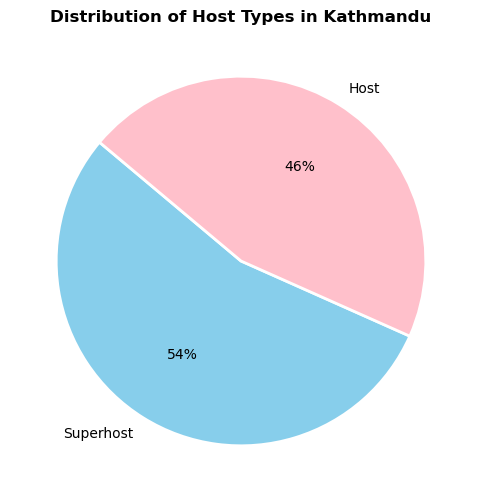

In [5]:
counts = df["Host Type"].value_counts()

plt.figure(figsize=(7,6))
plt.pie(counts.values, labels=counts.index, colors=["skyblue", "pink"], autopct="%1.0f%%", startangle=140, wedgeprops={"edgecolor": "white", "linewidth":2})
plt.title("Distribution of Host Types in Kathmandu", fontsize=12, fontweight="bold")
plt.savefig("chart1.png", dpi=150, bbox_inches="tight")
plt.show()

### Chart 2 - Ratings Distribution by Host Type

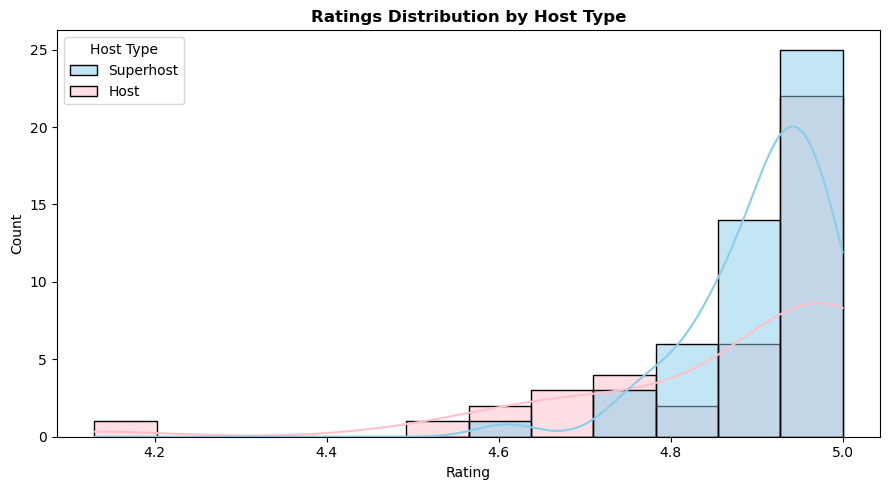

In [6]:
plt.figure(figsize=(9,5))
sns.histplot(data=df, x="Ratings", hue="Host Type", bins=12, palette={"Superhost": "skyblue", "Host": "pink"}, kde=True)
plt.title("Ratings Distribution by Host Type", fontsize=12, fontweight="bold")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("chart2.png", dpi=150, bbox_inches="tight")
plt.show()

### Chart 3 - Average Rating and Reviews by Host Type

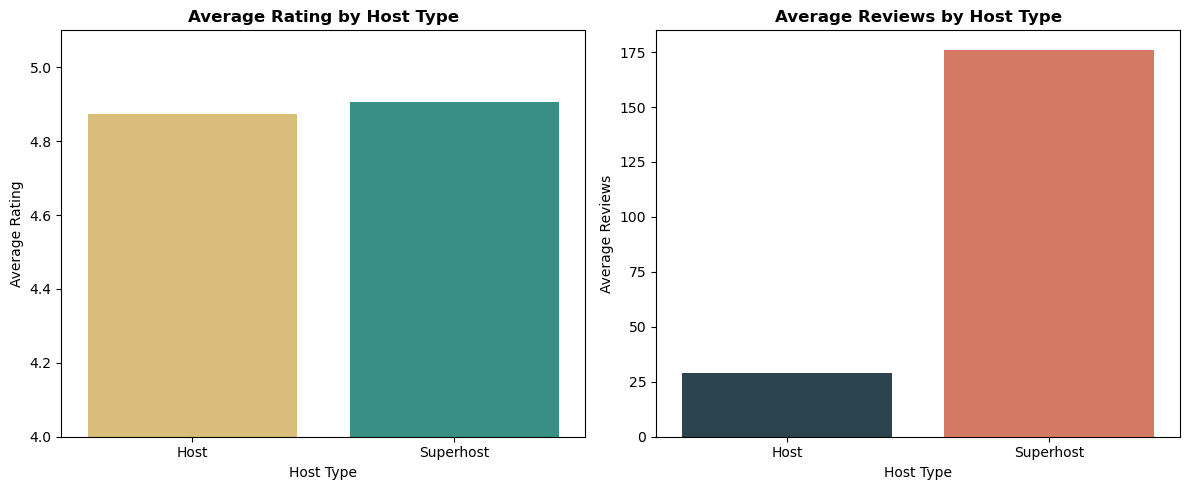

In [7]:
avg_r = df.groupby("Host Type", as_index=False)["Ratings"].mean()
avg_rev = df.groupby("Host Type", as_index=False)["Reviews"].mean()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.barplot(data=avg_r, x="Host Type", y="Ratings", hue="Host Type",
            palette={"Superhost": "#2A9D8F", "Host": "#E9C46A"})
plt.title("Average Rating by Host Type", fontweight="bold")
plt.ylim(4.0, 5.1)
plt.xlabel("Host Type")
plt.ylabel("Average Rating")

plt.subplot(1, 2, 2)
sns.barplot(data=avg_rev, x="Host Type", y="Reviews", hue="Host Type",
            palette={"Superhost": "#E76F51", "Host": "#264653"})
plt.title("Average Reviews by Host Type", fontweight="bold")
plt.xlabel("Host Type")
plt.ylabel("Average Reviews")

plt.tight_layout()
plt.savefig("chart3.png", dpi=150, bbox_inches="tight")
plt.show()

### Chart 4 - Top 15 Providers by Reviews

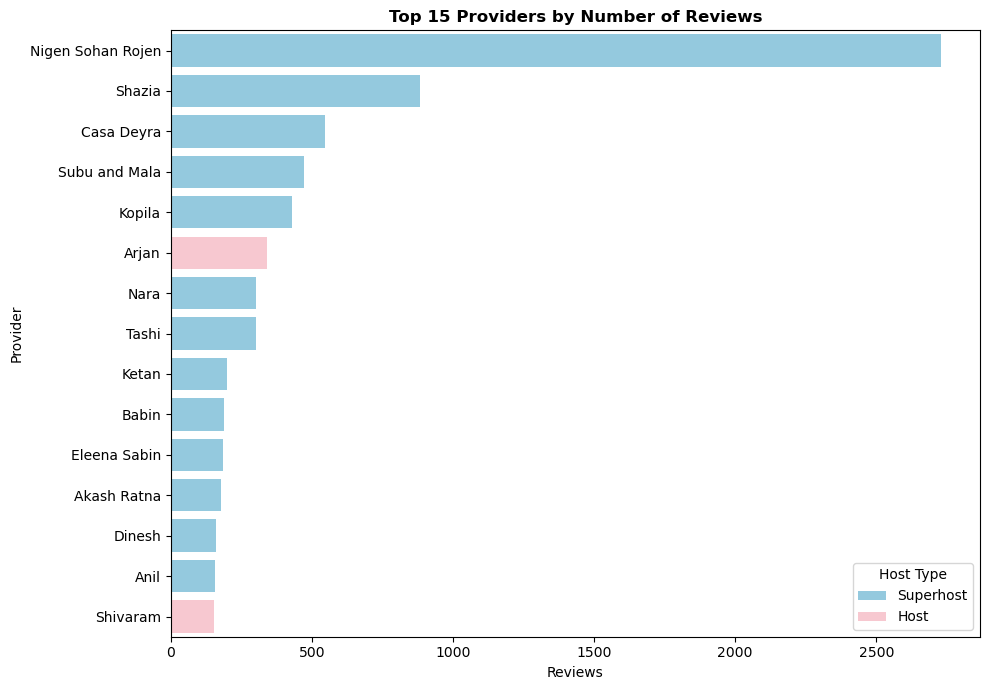

In [8]:
top15 = df.nlargest(15, "Reviews")

plt.figure(figsize=(10, 7))
sns.barplot(data=top15, y="Providers", x="Reviews", hue="Host Type",
            palette={"Superhost": "skyblue", "Host": "pink"})
plt.title("Top 15 Providers by Number of Reviews", fontweight="bold")
plt.xlabel("Reviews")
plt.ylabel("Provider")
plt.tight_layout()
plt.savefig("chart4.png", dpi=150, bbox_inches="tight")
plt.show()

### Chart 5 - Reviews vs Ratings Scatter Plot

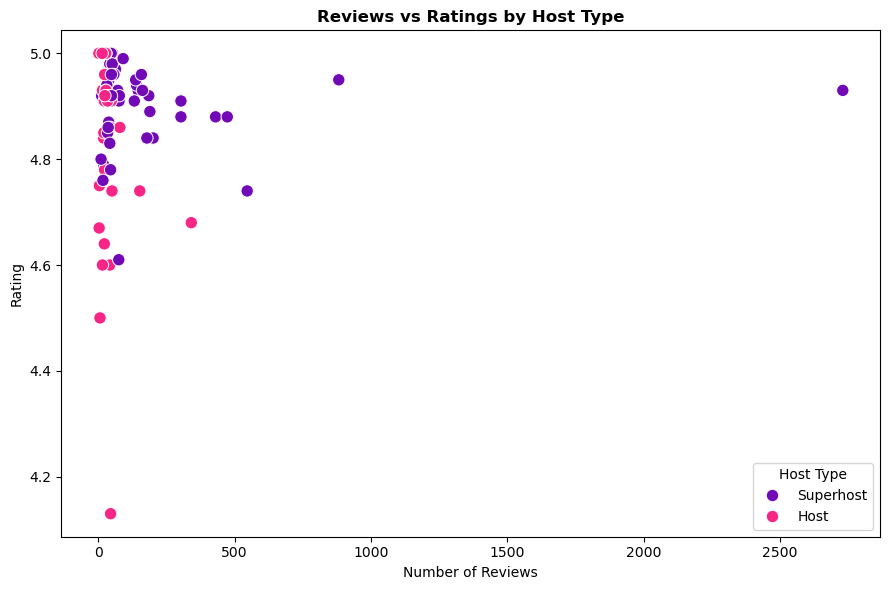

Correlation between Reviews and Ratings: -0.0076


In [9]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x="Reviews", y="Ratings", hue="Host Type",
                palette={"Superhost": "#7209B7", "Host": "#F72585"}, s=80)
plt.title("Reviews vs Ratings by Host Type", fontweight="bold")
plt.xlabel("Number of Reviews")
plt.ylabel("Rating")
plt.tight_layout()
plt.savefig("chart5.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Correlation between Reviews and Ratings: {df['Reviews'].corr(df['Ratings']):.4f}")

### Chart 6 - Providers by Hosting Experience Tier

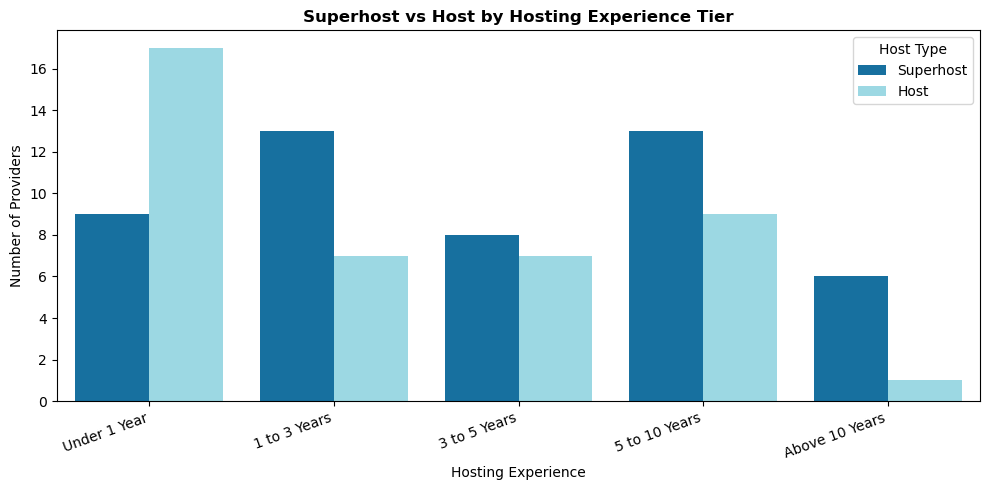

In [10]:
order = ["Under 1 Year", "1 to 3 Years", "3 to 5 Years", "5 to 10 Years", "Above 10 Years"]

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="Hosting Tier", hue="Host Type", order=order,
              palette={"Superhost": "#0077B6", "Host": "#90E0EF"})
plt.title("Superhost vs Host by Hosting Experience Tier", fontweight="bold")
plt.xlabel("Hosting Experience")
plt.ylabel("Number of Providers")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("chart6.png", dpi=150, bbox_inches="tight")
plt.show()